# Stage 1 — Data Acquisition Sanity Check

Lone star tick (*Amblyomma americanum*) range-expansion pipeline.

This notebook is a **read-only sanity report** over the raw Stage 1 pulls in `data/raw/`.
It does **not** clean, reproject, or modify anything. It reports:

1. Total record count (sample vs. full GBIF-matching count)
2. Records-per-year histogram
3. Share of records with valid coordinates
4. `basisOfRecord` breakdown
5. A static scatter of all occurrence points over a US outline

Figures are written to `reports/figures/`.

> **Which data is shown.** The loader auto-detects what's in `data/`:
> - If a GBIF **download-API** result is present (raw `.zip` + tab-separated
>   extract in `data/interim/`), it uses that — the **complete, DOI-citable** set.
> - Otherwise it falls back to a **search-API** CSV, which is partial and
>   recency-biased (GBIF throttles anonymous deep paging after ~10k records and
>   returns most-recent-first). The manifest fields `method` / `partial_pull` /
>   `completeness` record exactly which one you're looking at.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Make src/ importable regardless of where the kernel is launched from.
_here = Path.cwd()
_root = next((p for p in (_here, *_here.parents) if (p / "src" / "config.py").exists()), _here.parent)
sys.path.insert(0, str(_root / "src"))
import config  # noqa: E402

pd.set_option("display.max_columns", 50)
print("Project root :", _root)
print("Raw dir      :", config.RAW_DIR)
print("Figures dir  :", config.FIGURES_DIR)

Project root : C:\Users\Arv\OneDrive\Desktop\lone-star-tick-spread
Raw dir      : C:\Users\Arv\OneDrive\Desktop\lone-star-tick-spread\data\raw
Figures dir  : C:\Users\Arv\OneDrive\Desktop\lone-star-tick-spread\reports\figures


In [2]:
def latest_raw(prefix: str, ext: str) -> Path:
    """Most recent raw pull matching a prefix/extension (never mutates raw)."""
    matches = sorted(config.RAW_DIR.glob(f"{prefix}*.{ext}"))
    if not matches:
        raise FileNotFoundError(
            f"No {prefix}*.{ext} in {config.RAW_DIR}. Run src/acquire_gbif.py first."
        )
    return matches[-1]


def load_manifest(data_path: Path) -> dict:
    mpath = data_path.with_suffix(data_path.suffix + ".manifest.json")
    return json.loads(mpath.read_text(encoding="utf-8")) if mpath.exists() else {}


def load_primary_occurrences():
    """Load the lone star tick occurrence table.

    Prefers the GBIF **download-API** result (raw .zip + tab-separated SIMPLE_CSV
    extract in data/interim) — the complete, DOI-citable set. Falls back to a
    search-API CSV in data/raw (comma-separated, partial) if no download exists.
    """
    zips = sorted(config.RAW_DIR.glob("gbif_amblyomma_americanum*.zip"))
    if zips:
        manifest = load_manifest(zips[-1])
        extract = config.INTERIM_DIR / manifest["interim_extracted_csv"]
        return pd.read_csv(extract, sep="\t", low_memory=False), manifest, extract.name
    csv = latest_raw("gbif_amblyomma_americanum", "csv")  # search-API fallback
    return pd.read_csv(csv), load_manifest(csv), csv.name


df, primary_manifest, primary_source = load_primary_occurrences()
IS_FULL = primary_manifest.get("method") == "download_api"
DATA_LABEL = "full download" if IS_FULL else "partial search-API sample"

print("Loaded        :", primary_source)
print("Method        :", primary_manifest.get("method"), f"({DATA_LABEL})")
print("Rows          :", f"{len(df):,}")
if IS_FULL:
    print("GBIF DOI      :", primary_manifest.get("gbif_doi"))
    print("Download key  :", primary_manifest.get("gbif_download_key"))
else:
    print("Full matching :", f"{primary_manifest.get('gbif_total_matching_count', 'n/a'):,}")
    print("Completeness  :", primary_manifest.get("completeness"),
          "| partial:", primary_manifest.get("partial_pull"))
df.head()

Loaded        : gbif_amblyomma_americanum_us_2026-06-03_n38916.csv
Method        : download_api (full download)
Rows          : 38,916
GBIF DOI      : 10.15468/dl.p85b8y
Download key  : 0036018-260519110011954


,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,infraspecificEpithet,taxonRank,scientificName,verbatimScientificName,verbatimScientificNameAuthorship,countryCode,locality,stateProvince,occurrenceStatus,individualCount,publishingOrgKey,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,coordinatePrecision,elevation,elevationAccuracy,depth,depthAccuracy,eventDate,day,month,year,taxonKey,speciesKey,basisOfRecord,institutionCode,collectionCode,catalogNumber,recordNumber,identifiedBy,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue
0,910495630,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/668449,Animalia,Arthropoda,Arachnida,Ixodida,Ixodidae,Amblyomma,Amblyomma americanum,NaN,SPECIES,"Amblyomma americanum Linnaeus, 1758",Amblyomma americanum,NaN,US,NaN,Illinois,PRESENT,NaN,28eb1a3f-1c15-4a95-931a-4af90ecb574d,37.373663,-88.926733,1724.0,NaN,NaN,NaN,NaN,NaN,2014-05-08T02:38:38,8.0,5.0,2014.0,2184301,2184301,HUMAN_OBSERVATION,iNaturalist,Observations,668449,NaN,laurentaake,2014-05-09T02:26:15,CC_BY_NC_4_0,laurentaake,laurentaake,NaN,NaN,2026-05-30T03:12:06.023Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...
1,891020650,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/95875,Animalia,Arthropoda,Arachnida,Ixodida,Ixodidae,Amblyomma,Amblyomma americanum,NaN,SPECIES,"Amblyomma americanum Linnaeus, 1758",Amblyomma americanum,NaN,US,NaN,Virginia,PRESENT,NaN,28eb1a3f-1c15-4a95-931a-4af90ecb574d,38.746919,-77.115880,NaN,NaN,NaN,NaN,NaN,NaN,2012-05-27,27.0,5.0,2012.0,2184301,2184301,HUMAN_OBSERVATION,iNaturalist,Observations,95875,NaN,Katja Schulz,2012-06-24T22:28:32,CC0_1_0,Katja Schulz,Katja Schulz,NaN,NaN,2026-05-30T03:12:02.031Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...
2,6335009554,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/36337...,Animalia,Arthropoda,Arachnida,Ixodida,Ixodidae,Amblyomma,Amblyomma americanum,NaN,SPECIES,"Amblyomma americanum Linnaeus, 1758",Amblyomma americanum,NaN,US,NaN,Virginia,PRESENT,NaN,28eb1a3f-1c15-4a95-931a-4af90ecb574d,38.809520,-77.459372,20.0,NaN,NaN,NaN,NaN,NaN,2026-05-20T10:35:32,20.0,5.0,2026.0,2184301,2184301,HUMAN_OBSERVATION,iNaturalist,Observations,363377902,NaN,Cyrus Li,2026-05-20T15:48:16,CC_BY_NC_4_0,Cyrus Li,Cyrus Li,NaN,NaN,2026-05-30T03:09:25.701Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
3,6334974513,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/36304...,Animalia,Arthropoda,Arachnida,Ixodida,Ixodidae,Amblyomma,Amblyomma americanum,NaN,SPECIES,"Amblyomma americanum Linnaeus, 1758",Amblyomma americanum,NaN,US,NaN,New York,PRESENT,NaN,28eb1a3f-1c15-4a95-931a-4af90ecb574d,40.888253,-72.855287,69.0,NaN,NaN,NaN,NaN,NaN,2025-06-13T14:08:59,13.0,6.0,2025.0,2184301,2184301,HUMAN_OBSERVATION,iNaturalist,Observations,363043985,NaN,Karina M. Torres,2026-05-19T13:40:50,CC_BY_4_0,Karina M. Torres,Karina M. Torres,NaN,NaN,2026-05-30T02:47:47.077Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
4,6334974041,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/36519...,Animalia,Arthropoda,Arachnida,Ixodida,Ixodidae,Amblyomma,Amblyomma americanum,NaN,SPECIES,"Amblyomma americanum Linnaeus, 1758",Amblyomma americanum,NaN,US,NaN,Kansas,PRESENT,NaN,28eb1a3f-1c15-4a95-931a-4af90ecb574d,37.337742,-96.470853,NaN,NaN,NaN,NaN,NaN,NaN,2026-05-25T12:38:55,25.0,5.0,2026.0,2184301,2184301,HUMAN_OBSERVATION,iNaturalist,Observations,365194518,NaN,Alex,2026-05-25T21:05:28,CC0_1_0,Alex,Alex,NaN,NaN,2026-05-30T02:58:38.088Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...


## 1–4. Counts, coordinate validity, basisOfRecord

In [3]:
n_total = len(df)

# Valid coordinates: present, in-range, and not the null island (0, 0).
lat, lon = df["decimalLatitude"], df["decimalLongitude"]
valid_coord = (
    lat.between(-90, 90) & lon.between(-180, 180)
    & lat.notna() & lon.notna()
    & ~((lat == 0) & (lon == 0))
)
share_valid = valid_coord.mean()

print(f"Total records in sample      : {n_total:,}")
print(f"Records with valid coords    : {valid_coord.sum():,} ({share_valid:.2%})")
print(f"Year coverage (sample)       : {int(df['year'].min())}–{int(df['year'].max())}")
print(f"Share with year >= {config.DENSE_SIGNAL_START_YEAR}        : {(df['year'] >= config.DENSE_SIGNAL_START_YEAR).mean():.2%}")
print()
print("basisOfRecord breakdown:")
print(df["basisOfRecord"].value_counts(dropna=False).to_string())
print()
print("Top institutionCode:")
print(df["institutionCode"].value_counts(dropna=False).head(8).to_string())

Total records in sample      : 38,916
Records with valid coords    : 38,916 (100.00%)
Year coverage (sample)       : 1874–2026
Share with year >= 2015        : 94.41%

basisOfRecord breakdown:
basisOfRecord
HUMAN_OBSERVATION     22463
PRESERVED_SPECIMEN    16415
MATERIAL_SAMPLE          38

Top institutionCode:
institutionCode
NEON                                                               16068
NaN                                                                14598
iNaturalist                                                         7873
HWML                                                                 197
INHS                                                                  43
Centre for Biodiversity Genomics                                      26
Ohio State University Acarology Laboratory, Columbus, OH (OSAL)       22
UAM                                                                   14


Saved: C:\Users\Arv\OneDrive\Desktop\lone-star-tick-spread\reports\figures\stage1_records_per_year_and_basis.png


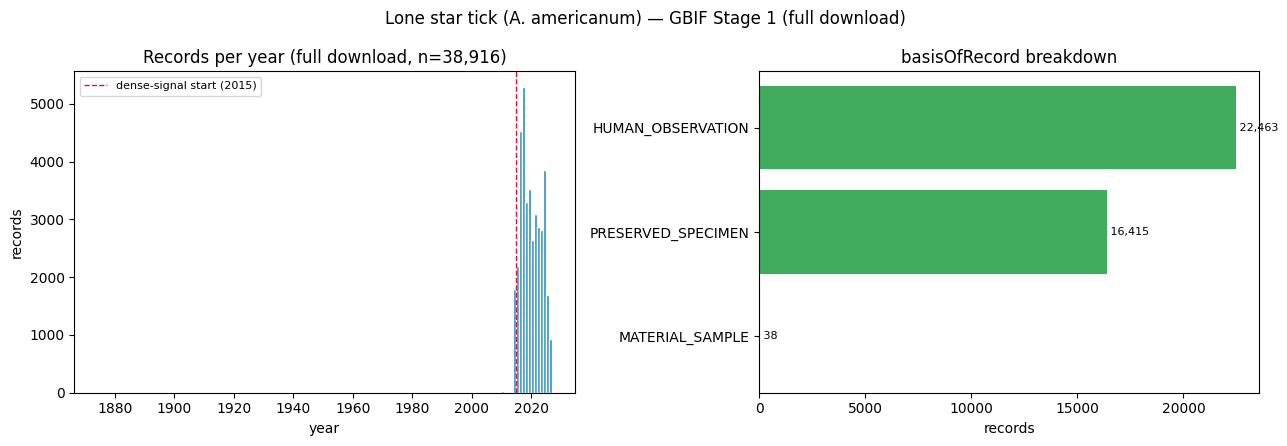

In [4]:
fig, (ax_year, ax_basis) = plt.subplots(1, 2, figsize=(13, 4.5))

years = df["year"].dropna().astype(int)
yr_min, yr_max = years.min(), years.max()
ax_year.hist(years, bins=range(yr_min, yr_max + 2), color="#2b8cbe", edgecolor="white")
ax_year.set_title(f"Records per year ({DATA_LABEL}, n={len(df):,})")
ax_year.set_xlabel("year")
ax_year.set_ylabel("records")
ax_year.axvline(config.DENSE_SIGNAL_START_YEAR, color="crimson", ls="--", lw=1,
                label=f"dense-signal start ({config.DENSE_SIGNAL_START_YEAR})")
ax_year.legend(fontsize=8)

basis = df["basisOfRecord"].value_counts()
ax_basis.barh(basis.index[::-1], basis.values[::-1], color="#41ab5d")
ax_basis.set_title("basisOfRecord breakdown")
ax_basis.set_xlabel("records")
for i, v in enumerate(basis.values[::-1]):
    ax_basis.text(v, i, f" {v:,}", va="center", fontsize=8)

fig.suptitle(f"Lone star tick (A. americanum) — GBIF Stage 1 ({DATA_LABEL})", fontsize=12)
fig.tight_layout()

config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
out = config.FIGURES_DIR / "stage1_records_per_year_and_basis.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print("Saved:", out)
plt.show()

## 5. Occurrence points over a US outline

Raw WGS84 (EPSG:4326) coordinates — **no reprojection** (that happens in a later
stage, to EPSG:5070). The US states outline is fetched once and cached to
`data/interim/`; if it can't be fetched, we fall back to a plain CONUS-extent
scatter so the sanity check still runs offline.

US states outline: 52 features


Saved: C:\Users\Arv\OneDrive\Desktop\lone-star-tick-spread\reports\figures\stage1_occurrence_map.png


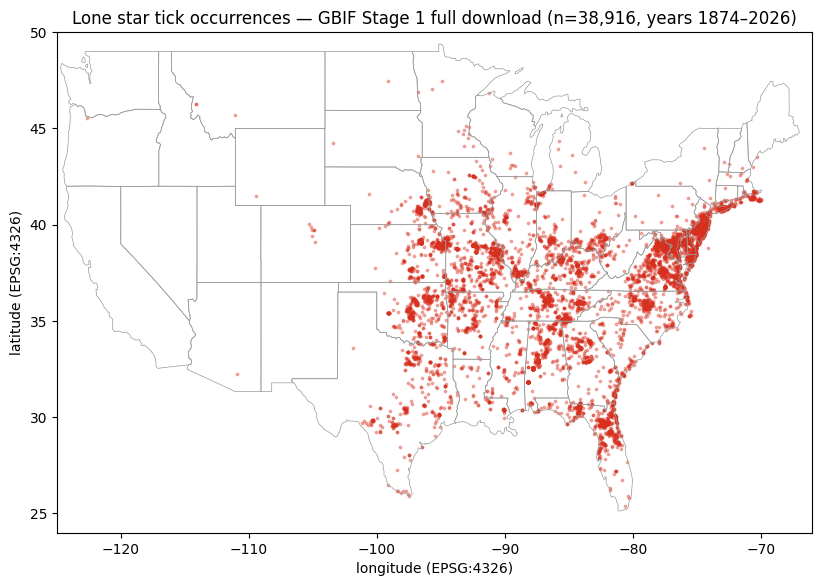

In [5]:
import geopandas as gpd

BASEMAP_URL = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
basemap_cache = config.INTERIM_DIR / "us_states.geojson"

states = None
try:
    if basemap_cache.exists():
        states = gpd.read_file(basemap_cache)
    else:
        states = gpd.read_file(BASEMAP_URL)
        states.to_file(basemap_cache, driver="GeoJSON")  # cache for offline reruns
    print("US states outline:", len(states), "features")
except Exception as exc:  # noqa: BLE001 - sanity check must still run offline
    print("Basemap unavailable, falling back to plain scatter:", exc)

# CONUS display window (keeps AK/HI/territory outliers from dominating the view).
CONUS = dict(xmin=-125, xmax=-66, ymin=24, ymax=50)

gdf = gpd.GeoDataFrame(
    df.loc[valid_coord],
    geometry=gpd.points_from_xy(df.loc[valid_coord, "decimalLongitude"],
                                df.loc[valid_coord, "decimalLatitude"]),
    crs=config.RAW_CRS,
)

fig, ax = plt.subplots(figsize=(11, 6.5))
if states is not None:
    states.boundary.plot(ax=ax, color="0.6", linewidth=0.5)
gdf.plot(ax=ax, markersize=3, color="#d7301f", alpha=0.35)
ax.set_xlim(CONUS["xmin"], CONUS["xmax"])
ax.set_ylim(CONUS["ymin"], CONUS["ymax"])
ax.set_xlabel("longitude (EPSG:4326)")
ax.set_ylabel("latitude (EPSG:4326)")
ax.set_title(
    f"Lone star tick occurrences — GBIF Stage 1 {DATA_LABEL} "
    f"(n={int(valid_coord.sum()):,}, years {int(df['year'].min())}–{int(df['year'].max())})"
)

out_map = config.FIGURES_DIR / "stage1_occurrence_map.png"
fig.savefig(out_map, dpi=150, bbox_inches="tight")
print("Saved:", out_map)
plt.show()

## CDC validation layer (context)

County-level establishment status — the validation target for later stages.
Remember: **established status is sticky/monotonic**, so this is a *cumulative
footprint* through the dataset's vintage year, not an annual snapshot.

In [6]:
cdc_path = latest_raw("cdc_amblyomma_americanum", "xlsx")
cdc = pd.read_excel(cdc_path)
status_col = next(c for c in cdc.columns if "Status" in c)

print("Loaded:", cdc_path.name)
print("Counties in file:", f"{len(cdc):,}")
print()
print(f"County status breakdown ({status_col}):")
print(cdc[status_col].value_counts(dropna=False).to_string())

established = cdc[cdc[status_col].astype(str).str.contains("Establish", case=False, na=False)]
print(f"\nEstablished counties (cumulative footprint): {len(established):,}")
print("States with most established counties:")
print(established["State"].value_counts().head(8).to_string())

Loaded: cdc_amblyomma_americanum_established_2026-06-03.xlsx
Counties in file: 3,110

County status breakdown (2025 County Status of A. americanum):
2025 County Status of A. americanum
No records     1336
Established    1139
Reported        635

Established counties (cumulative footprint): 1,139
States with most established counties:
State
TX    118
KY     86
AR     73
VA     70
OK     69
IL     68
MO     63
GA     60


## Sanity-check takeaways / caveats

- **Data source is recorded in the manifest** (`method` printed above). The
  download-API set is the complete ~38.9k georeferenced US records (DOI-citable,
  full historical depth back to the 1800s); the search-API fallback is partial
  and recency-biased and should not be used for the year-by-year analysis.
- **Coordinates are raw EPSG:4326** — intentionally un-reprojected here.
- **CDC layer is a cumulative footprint** (sticky "established"), vintage = the
  year in the status column above.
- The dense, mappable citizen-science signal is roughly **2015 → present**, so
  the eventual time-lapse will be recent-weighted even though records exist for
  much earlier decades.